In [1]:
import numpy as np
from qiskit import QuantumCircuit

In [2]:
rng = np.random.default_rng()
bit_num = 20
qc = QuantumCircuit(bit_num, bit_num)

### Quantum Key Distribution 

In [3]:
#Random bits and bases for Alice
#generating Alice's random bits
abits = np.round(rng.random(bit_num))
#generating Alice's random measurement bases.
abase = np.round(rng.random(bit_num))
#Here we will associate a "0" with the Z basis, and a "1" with the X basis.

In [4]:
#Preparing Alice's state
for n in range(bit_num):
    if abits[n] == 0:
        if abase[n] == 1:
            qc.h(n)
    if abits[n] == 1:
        if abase[n] == 0:
            qc.x(n)
        if abase[n] == 1:
            qc.x(n)
            qc.h(n)
 
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=20, num_clbits=0, params=[]), qubits=(<Qubit register=(20, "q"), index=0>, <Qubit register=(20, "q"), index=1>, <Qubit register=(20, "q"), index=2>, <Qubit register=(20, "q"), index=3>, <Qubit register=(20, "q"), index=4>, <Qubit register=(20, "q"), index=5>, <Qubit register=(20, "q"), index=6>, <Qubit register=(20, "q"), index=7>, <Qubit register=(20, "q"), index=8>, <Qubit register=(20, "q"), index=9>, <Qubit register=(20, "q"), index=10>, <Qubit register=(20, "q"), index=11>, <Qubit register=(20, "q"), index=12>, <Qubit register=(20, "q"), index=13>, <Qubit register=(20, "q"), index=14>, <Qubit register=(20, "q"), index=15>, <Qubit register=(20, "q"), index=16>, <Qubit register=(20, "q"), index=17>, <Qubit register=(20, "q"), index=18>, <Qubit register=(20, "q"), index=19>), clbits=())

In [5]:
#generating random measurement bases for Bob
bbase =  np.round(rng.random(bit_num))

In [6]:
#Note that if Bob measures in Z no gates are necessary, since IBM Quantum computers measure in Z by default.
#If Bob measures in the X basis, we implement a hadamard gate qc.h to facilitate the measurement.
 
for m in range(bit_num):
    if bbase[m] == 1:
        qc.h(m)
    qc.measure(m, m)

Alice's bits are  [1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1.]
Alice's bases are  [1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 0.]
Bob's bases are  [0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 1.]


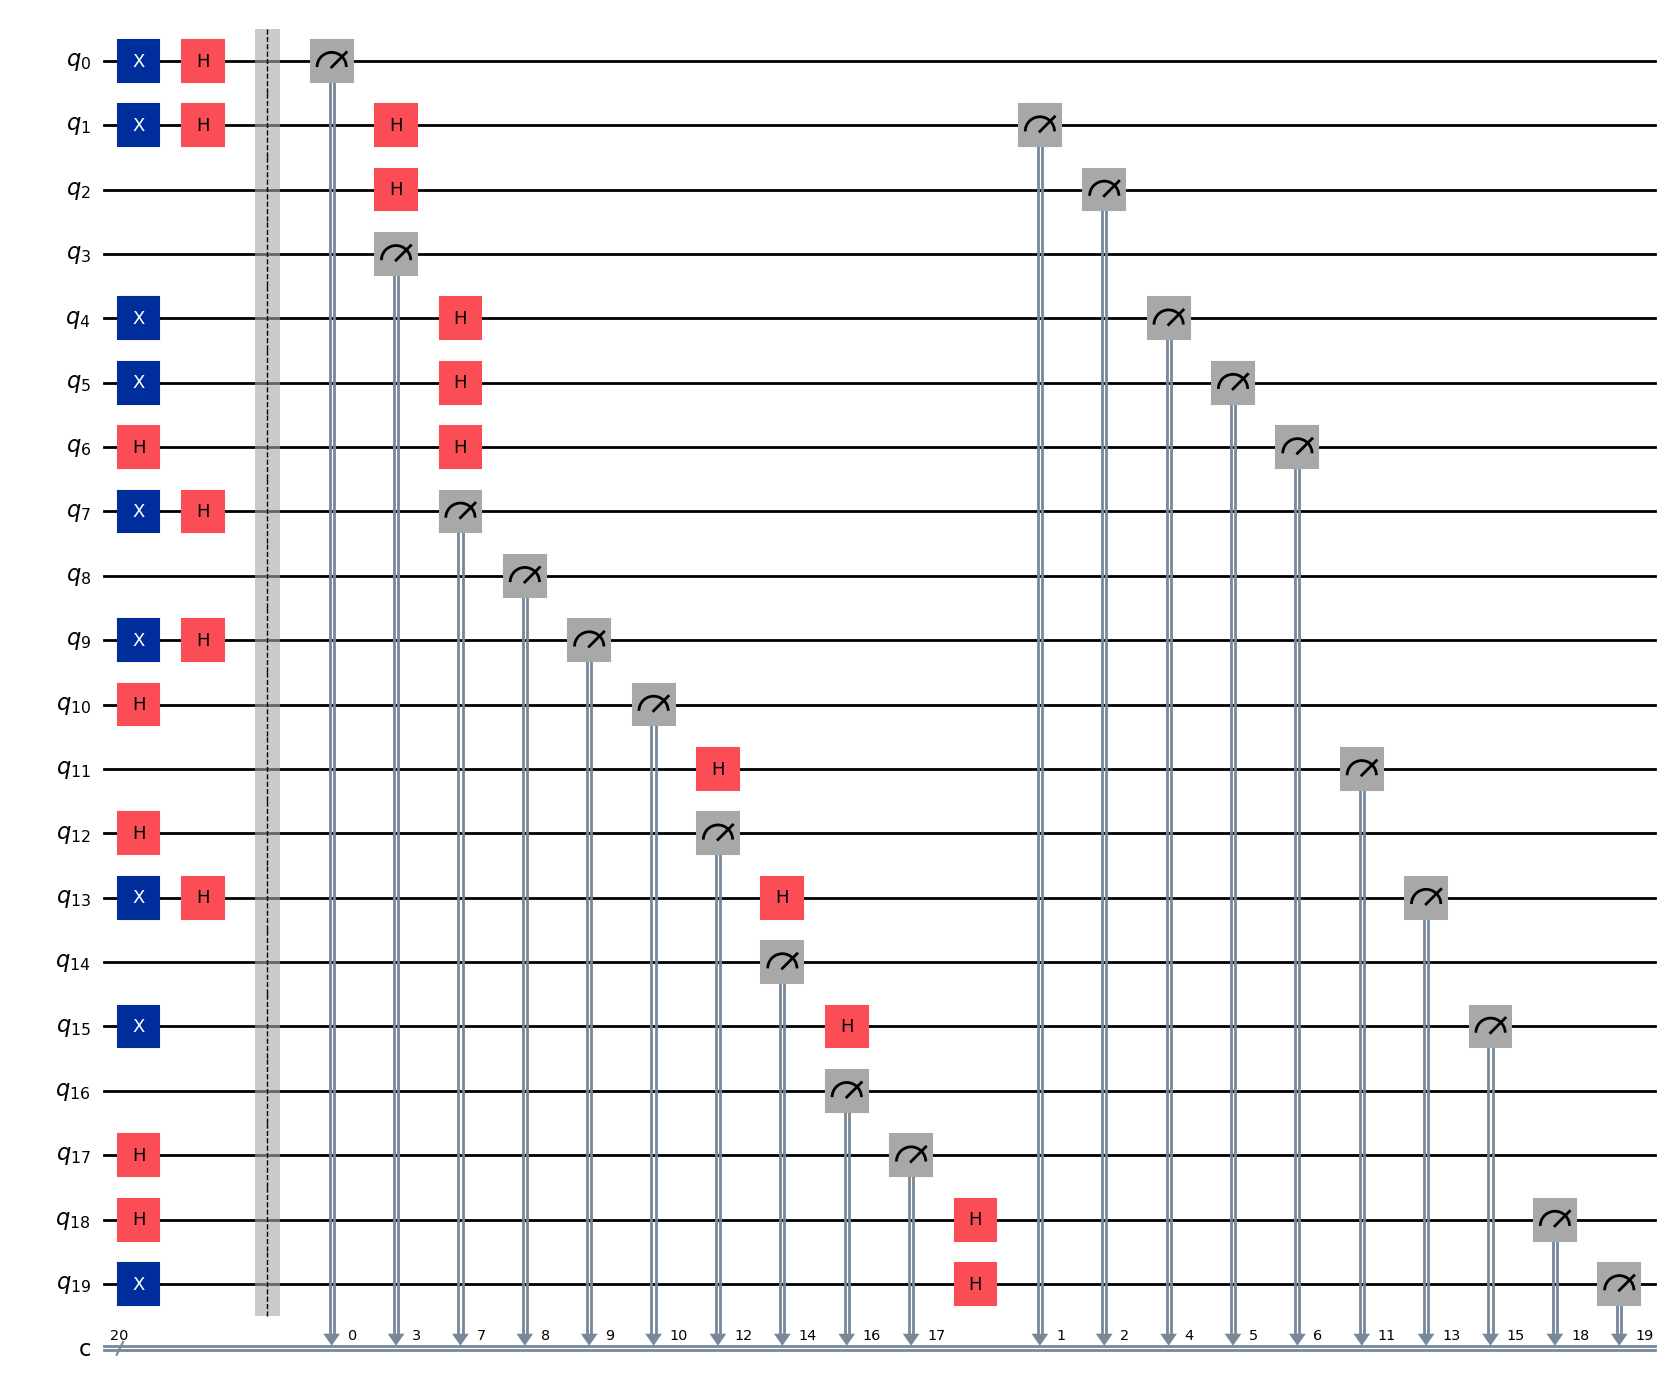

In [7]:
print("Alice's bits are ", abits)
print("Alice's bases are ", abase)
print("Bob's bases are ", bbase)
qc.draw("mpl")